# 02 · 할인율 — 같은 약속, 다른 숫자

[![Colab에서 열기](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/keerhee/pension-fund-strategy-and-performance/blob/main/W06_LDI%EC%99%80GBI/W06_M7_%EC%8B%A4%EC%8A%B5_Colab/02_%ED%95%A0%EC%9D%B8%EC%9C%A8.ipynb)

**W06 M7 LDI 강의본 단원 ②(18~28장)** 의 숫자를 재현합니다. 할인율(부채를 재는 자)을 바꾸면 같은 약속이 다른 부채가 됩니다.

| 단계 | 강의 | 이 노트북에서 |
|---|---|---|
| 먼 약속일수록 흔들린다 | 19장 | 20년 뒤 100: 5% → 37.7 · 3% → 55.4 · 2%p 낮추면 +47% |
| 할인율의 두 눈금 — 국민연금 | 20 · 21 · 23장 | 자체 5.5% → 순부채 1,542조 · FR 95% / 국채 곡선 → 2,122조 · FR 69% · 1.4배 |
| 할인율 선택표 | 14 · 20장 | 예상수익률 7~8% · 국채 3~5% · AA 회사채(+100~150bp) — "두 배까지" |
| 공무원연금 · CalPERS | 21~23장 | 기금 16조 ÷ 부채 900조+ = 2% 미만 · CalPERS 7.5% → 6.8% |
| 영국 DB의 세 자 | 24 · 25장 | 잉여금 £273.7B · FR 130.8% → A ≈ £1,162B · L ≈ £889B / 바이아웃 114% → L ≈ £1,000B · 약 12% |

국민연금 숫자는 **케이스 데이터(교육용 추계)** 의 순유출(급여 − 보험료)을 노트북 안 상수로 옮겨 계산합니다(출처: `W06_M7_케이스데이터/fml_w6m7_cashflow.csv` · `fml_w6m7_curve.csv`, 계산 방식은 `w6m7_compute.py`와 같음).

### 0. 준비 — 이 셀부터 실행
한글 폰트(Colab은 나눔고딕 설치, 맥은 Pretendard), 강의 색(잉크 · 라임 · 티일 · 빨강), 강의본 숫자 확인 함수 `check()`를 준비합니다.
`check(이름, 계산값, 강의값, 허용오차)`는 계산이 강의본 숫자와 허용오차 안에서 맞는지 확인하고, 틀리면 멈춥니다(`assert`).
가정을 바꿔 실험할 때는 `FAST = True`로 두면 확인이 멈추지 않고 ✗로 표시만 합니다(M7 세트는 계산이 가벼워 속도 차이는 없음).

In [1]:
# ── 환경 준비: 한글 폰트 · 강의 색 · 확인 함수 (이 셀을 먼저 실행) ──
import sys, os, glob, math, time, subprocess
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm

import warnings
warnings.filterwarnings("ignore", message=".*encountered in matmul")   # 맥 numpy(Accelerate)의 거짓 경고 — 결과와 무관
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB and not glob.glob("/usr/share/fonts/truetype/nanum/NanumGothic*.ttf"):
    # Colab: 나눔 폰트 설치 (= !apt-get -qq install -y fonts-nanum) — 처음 한 번 10초 안팎
    subprocess.run("apt-get -qq install -y fonts-nanum > /dev/null", shell=True)

def setup_korean_font():
    """로컬 맥은 Pretendard, Colab은 나눔고딕을 matplotlib에 등록한다(폰트 캐시 갱신과 같은 효과)."""
    files = (glob.glob(os.path.expanduser("~/Library/Fonts/Pretendard-*.otf"))
             + glob.glob("/Library/Fonts/Pretendard-*.otf")
             + glob.glob("/usr/share/fonts/truetype/nanum/NanumGothic*.ttf"))
    for f in files:
        try:
            fm.fontManager.addfont(f)
        except Exception:
            pass
    names = {f.name for f in fm.fontManager.ttflist}
    for fam in ["Pretendard", "NanumGothic", "AppleGothic", "Malgun Gothic", "Noto Sans CJK KR"]:
        if fam in names:
            plt.rcParams["font.family"] = fam
            return fam
    return "(한글 폰트 없음 — 그래프 글자가 네모로 보이면 이 셀을 다시 실행)"

FONT = setup_korean_font()
plt.rcParams["axes.unicode_minus"] = False

# 강의 색 — 잉크 · 라임 · 티일 · 빨강 (+ 보조 회색 · 아이보리 바탕)
INK, LIME, TEAL, RED = "#071A1D", "#B7F34A", "#0B6B68", "#C00000"
GRAY, IVORY, OLIVE = "#8A9496", "#F7F5F0", "#5E8C1A"
plt.rcParams.update({
    "figure.figsize": (8, 4.5), "figure.dpi": 110, "savefig.dpi": 110,
    "figure.facecolor": "white", "axes.facecolor": IVORY,
    "axes.edgecolor": INK, "axes.labelcolor": INK, "xtick.color": INK, "ytick.color": INK,
    "axes.titleweight": "bold", "axes.titlesize": 13, "axes.titlelocation": "left",
    "axes.grid": True, "grid.color": "#DDD8CC", "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "legend.frameon": False, "axes.axisbelow": True,
    "axes.prop_cycle": matplotlib.cycler(color=[TEAL, INK, RED, OLIVE, GRAY]),
})

# 빠른 모드 — M7 세트는 계산이 가벼워 FAST가 결과를 바꾸지 않는다. True면 확인(check)이 멈추지 않고 표시만 한다(숫자를 바꿔 실험할 때)
FAST = False

CHECKS = []
def check(label, value, lecture, tol, fmt=".4f", unit=""):
    """계산값을 강의본 숫자와 비교한다. 기본(재현) 모드에서는 허용오차를 넘으면 멈춘다(assert)."""
    ok = abs(value - lecture) <= tol + 1e-9      # 허용오차는 보통 강의 표기 자릿수의 반(반올림하면 같은 값)
    CHECKS.append((label, ok))
    print(f"{'✓' if ok else '✗'} {label}: 계산 {value:{fmt}}{unit} · 강의 {lecture:{fmt}}{unit} (허용 ±{tol:g})")
    if not FAST:
        assert ok, f"{label}: 계산 {value} · 강의 {lecture}"

print(f"Colab: {IN_COLAB} · 그래프 폰트: {FONT} · numpy {np.__version__} · matplotlib {matplotlib.__version__}")

Colab: False · 그래프 폰트: Pretendard · numpy 2.0.2 · matplotlib 3.9.4


## 1. 먼 약속일수록 흔들린다 (강의 19장)
20년 뒤 100을 한 번 지급하는 약속. 할인은 분모의 (1 + r)ᵗ로 하니 **r의 차이가 t번 곱해집니다.**

In [2]:
def pv(cf, r, t):
    return cf / (1 + r) ** t

v5, v3 = pv(100, 0.05, 20), pv(100, 0.03, 20)
print(f"5%: 100 ÷ 1.05²⁰ = {v5:.1f} · 3%: 100 ÷ 1.03²⁰ = {v3:.1f} → 할인율 2%p 낮추면 부채 {v3 / v5 - 1:+.0%}")
check("20년 뒤 100 · 5%", v5, 37.7, 0.05, ".1f")
check("20년 뒤 100 · 3%", v3, 55.4, 0.05, ".1f")
check("2%p 낮출 때 부채 증가 (%)", 100 * (v3 / v5 - 1), 47, 0.5, ".1f")

5%: 100 ÷ 1.05²⁰ = 37.7 · 3%: 100 ÷ 1.03²⁰ = 55.4 → 할인율 2%p 낮추면 부채 +47%
✓ 20년 뒤 100 · 5%: 계산 37.7 · 강의 37.7 (허용 ±0.05)
✓ 20년 뒤 100 · 3%: 계산 55.4 · 강의 55.4 (허용 ±0.05)
✓ 2%p 낮출 때 부채 증가 (%): 계산 46.9 · 강의 47.0 (허용 ±0.5)


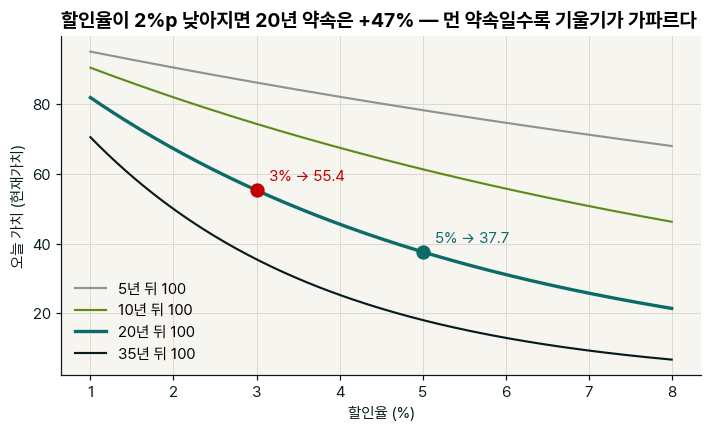

In [3]:
rs = np.linspace(0.01, 0.08, 200)
fig, ax = plt.subplots(figsize=(7.5, 4))
for t, c in [(5, GRAY), (10, OLIVE), (20, TEAL), (35, INK)]:
    ax.plot(rs * 100, pv(100, rs, t), color=c, lw=2.2 if t == 20 else 1.4, label=f"{t}년 뒤 100")
for r_, v in [(3, v3), (5, v5)]:
    ax.scatter(r_, v, s=70, color=RED if r_ == 3 else TEAL, zorder=5)
    ax.annotate(f"{r_}% → {v:.1f}", (r_, v), textcoords="offset points", xytext=(8, 6), color=RED if r_ == 3 else TEAL)
ax.set_xlabel("할인율 (%)"); ax.set_ylabel("오늘 가치 (현재가치)")
ax.set_title("할인율이 2%p 낮아지면 20년 약속은 +47% — 먼 약속일수록 기울기가 가파르다")
ax.legend()
plt.show()

## 2. 할인율의 두 눈금 — 국민연금 순부채 (강의 20 · 21 · 23장)
2026~2071년 순유출(급여 − 보험료)의 현재가치를 두 자로 잽니다(2025년 말 기준, 연말 현금흐름).
- **자체 할인율 5.5%** (연금개혁 전제 기금수익률)
- **국채 곡선** — 국고채 3 · 10 · 30 · 50년 공시 수익률(2026-09-18) + 교육용 보간, 만기 t년 현금흐름은 t년 금리로 할인

적립금 F = 1,458조(2025년 말)로 나누면 적립비율 두 개가 나옵니다. **우리 계산** 값이며, 국민연금이 공시하는 지표는 적립배율(적립금 ÷ 그해 지출)입니다.

In [4]:
# 케이스 데이터 상수 (교육용 추계 · 조원) — 출처: W06_M7_케이스데이터/fml_w6m7_cashflow.csv (net_outflow_trn_krw, 2026~2071)
YEARS = np.arange(2026, 2072)
NET = np.array([
    -14, -15.09, -16.06, -16.89, -17.57, -18.07, -18.38, -18.46, -13.92, -8.9,
    -3.38, 2.69, 9.36, 16.66, 24.66, 33.4, 42.95, 53.37, 64.72, 77.09,
    90.55, 105.18, 121.09, 138.36, 157.1, 175.05, 194.37, 215.16, 237.52, 261.55,
    287.39, 315.15, 344.96, 376.97, 411.33, 448.2, 487.76, 530.2, 575.7, 624.49,
    676.79, 732.84, 792.89, 857.23, 926.15, 961.84,
])          # 순유출 = 급여 − 보험료 (음수 = 보험료가 더 많은 해)
MATS = np.array([1.0, 2.0, 3.0, 5.0, 10.0, 20.0, 30.0, 50.0])                    # 국고채 곡선 만기(년) — fml_w6m7_curve.csv
YLDS = np.array([3.95, 4.0, 4.06, 4.25, 4.47, 4.58, 4.6, 4.55])   # 수익률(%) — 3 · 10 · 30 · 50년 공시, 나머지 교육용 보간
F0 = 1458.0          # 2025년 말 적립금(조)
HURDLE = 5.5         # 자체 할인율 = 허들(%)

def z(t, shift_bp=0.0):
    """만기 t년 금리(%) — 곡선 점을 선형 보간, 50년 뒤는 평탄"""
    return np.interp(t, MATS, YLDS) + shift_bp / 100

def pv_flows(flows, years, rate=None, shift_bp=0.0):
    """연말 현금흐름의 2025년 말 현재가치 — rate(%)가 있으면 평탄 할인, 없으면 곡선"""
    t = np.asarray(years) - 2025
    r = np.full(t.shape, rate, dtype=float) if rate is not None else z(t, shift_bp)
    return float(np.sum(flows / (1 + r / 100) ** t))

L_h = pv_flows(NET, YEARS, rate=HURDLE)
L_g = pv_flows(NET, YEARS)
print(f"곡선: 3년 {z(3):.2f} · 10년 {z(10):.2f} · 30년 {z(30):.2f}%")
print(f"순부채 — 자체 {HURDLE}%: {L_h:,.0f}조 · 국채 곡선: {L_g:,.0f}조 (×{L_g / L_h:.2f})")
print(f"적립비율 — 자체 FR_h = {F0 / L_h:.0%} · 국채 FR_g = {F0 / L_g:.0%}")
check("순부채 자체 5.5% (조)", L_h, 1542, 0.5, ",.0f")
check("순부채 국채 곡선 (조)", L_g, 2122, 0.5, ",.0f")
check("FR 자체 눈금 (%)", 100 * F0 / L_h, 95, 0.5, ".1f")
check("FR 국채 눈금 (%)", 100 * F0 / L_g, 69, 0.5, ".1f")
check("두 눈금의 비 (배)", L_g / L_h, 1.4, 0.05, ".2f")

곡선: 3년 4.06 · 10년 4.47 · 30년 4.60%
순부채 — 자체 5.5%: 1,542조 · 국채 곡선: 2,122조 (×1.38)
적립비율 — 자체 FR_h = 95% · 국채 FR_g = 69%
✓ 순부채 자체 5.5% (조): 계산 1,542 · 강의 1,542 (허용 ±0.5)
✓ 순부채 국채 곡선 (조): 계산 2,122 · 강의 2,122 (허용 ±0.5)
✓ FR 자체 눈금 (%): 계산 94.6 · 강의 95.0 (허용 ±0.5)
✓ FR 국채 눈금 (%): 계산 68.7 · 강의 69.0 (허용 ±0.5)
✓ 두 눈금의 비 (배): 계산 1.38 · 강의 1.40 (허용 ±0.05)


**그래프 — 평탄 할인율을 바꿔 가며 잰 순부채와 적립비율.** 할인율 하나가 적립비율을 50%대에서 100% 위까지 옮깁니다.
국채 곡선(4% 중반)은 평탄 할인율로 치면 어디쯤인지도 찾아 봅니다(곡선 부채와 같은 값을 주는 평탄 할인율).

국채 곡선 부채 2,122조 = 평탄 할인율 4.58%와 같다


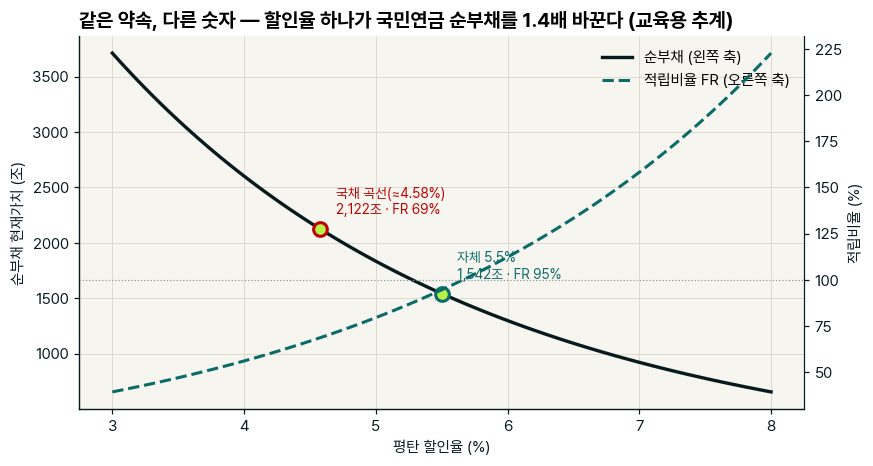

In [5]:
from scipy.optimize import brentq
flat = np.linspace(3.0, 8.0, 101)
Ls = np.array([pv_flows(NET, YEARS, rate=x) for x in flat])
r_equiv = brentq(lambda x: pv_flows(NET, YEARS, rate=x) - L_g, 2, 8)
print(f"국채 곡선 부채 {L_g:,.0f}조 = 평탄 할인율 {r_equiv:.2f}%와 같다")

fig, ax1 = plt.subplots(figsize=(8.5, 4.4))
ax1.plot(flat, Ls, color=INK, lw=2.2, label="순부채 (왼쪽 축)")
ax1.set_xlabel("평탄 할인율 (%)"); ax1.set_ylabel("순부채 현재가치 (조)")
ax2 = ax1.twinx()
ax2.plot(flat, 100 * F0 / Ls, color=TEAL, lw=2, ls="--", label="적립비율 FR (오른쪽 축)")
ax2.axhline(100, color=GRAY, lw=0.8, ls=":")
ax2.set_ylabel("적립비율 (%)"); ax2.spines["right"].set_visible(True); ax2.grid(False)
for x, L_, lab, c in [(HURDLE, L_h, f"자체 5.5%\n{L_h:,.0f}조 · FR {F0 / L_h:.0%}", TEAL), (r_equiv, L_g, f"국채 곡선(≈{r_equiv:.2f}%)\n{L_g:,.0f}조 · FR {F0 / L_g:.0%}", RED)]:
    ax1.scatter(x, L_, s=80, color=LIME, edgecolor=c, lw=2, zorder=6)
    ax1.annotate(lab, (x, L_), textcoords="offset points", xytext=(10, 10), color=c, fontsize=9)
ax1.set_title("같은 약속, 다른 숫자 — 할인율 하나가 국민연금 순부채를 1.4배 바꾼다 (교육용 추계)")
h1, l1 = ax1.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="upper right")
plt.show()

## 3. 할인율 선택표 — "두 배까지 차이" (강의 14 · 20장)
| 할인율 | 사용 주체 | 특징 |
|---|---|---|
| 예상 자산수익률 7~8% | 미국 공적연금 전통 | 부채가 작아 보인다 — "많이 벌 테니 부채가 작다"는 순환 논리 |
| 국채 수익률 3~5% | 민간 연금(ERISA · IAS 19) | 시장 가격 반영 — 부채가 크고 금리에 따라 크게 변한다 |
| AA 회사채 | 미국 GAAP | 국채 + 스프레드 100~150bp |

같은 국민연금 순유출에 이 눈금들을 대 봅니다(평탄 할인율로 단순화한 비교).

In [6]:
scales = [("국채 3%", 3.0), ("국채 곡선", None), ("AA 회사채 = 곡선 + 125bp", "aa"), ("자체 5.5%", 5.5), ("예상수익률 7.5%", 7.5)]
vals = []
for name, x in scales:
    if x is None: v = L_g
    elif x == "aa": v = pv_flows(NET, YEARS, shift_bp=125)
    else: v = pv_flows(NET, YEARS, rate=x)
    vals.append(v)
    print(f"{name:22s} 순부채 {v:7,.0f}조 · FR {F0 / v:5.0%}")
print(f"가장 낮은 자(3%) ÷ 가장 높은 자(7.5%) = {vals[0] / vals[-1]:.1f}배")
print("강의 14장은 일반 연금 기준 '두 배까지'. 국민연금 순유출은 앞쪽이 보험료 유입(음수)이고 지급이 먼 뒤에 몰려(듀레이션 35년)")
print("같은 눈금 차이에도 배수가 훨씬 크다 — 부채가 길수록 '자'의 선택이 더 큰 숫자를 만든다")
check("국채 3% vs 예상수익률 7.5% — 두 배 이상", float(vals[0] / vals[-1] >= 2), 1, 0, ".0f")

국채 3%                  순부채   3,711조 · FR   39%
국채 곡선                  순부채   2,122조 · FR   69%
AA 회사채 = 곡선 + 125bp    순부채   1,375조 · FR  106%
자체 5.5%                순부채   1,542조 · FR   95%
예상수익률 7.5%             순부채     776조 · FR  188%
가장 낮은 자(3%) ÷ 가장 높은 자(7.5%) = 4.8배
강의 14장은 일반 연금 기준 '두 배까지'. 국민연금 순유출은 앞쪽이 보험료 유입(음수)이고 지급이 먼 뒤에 몰려(듀레이션 35년)
같은 눈금 차이에도 배수가 훨씬 크다 — 부채가 길수록 '자'의 선택이 더 큰 숫자를 만든다
✓ 국채 3% vs 예상수익률 7.5% — 두 배 이상: 계산 1 · 강의 1 (허용 ±0)


## 4. 공무원연금 · CalPERS (강의 21 · 22 · 23장)
- 공무원연금: 기금 16조 · 연금충당부채 900조+ → 적립비율 **2% 미만**(우리 계산). 2015 개혁: 기여율 7% → 9%, 지급률 1.9% → 1.7%.
- CalPERS: 할인율 7.5% → 6.8%(2016년 단계적 하향), 적립비율 약 75%(FY2024, 공시).

CalPERS의 0.7%p 하향이 어느 정도의 부채 증가인지, 같은 국민연금 순유출로 감을 잡아 봅니다(교육용 비교 — 강의 숫자 아님).

In [7]:
gepf = 16 / 900
print(f"공무원연금 적립비율 ≈ 16 ÷ 900 = {gepf:.1%} (부채가 900조보다 크면 더 낮다)")
check("공무원연금 적립비율 2% 미만", float(gepf < 0.02), 1, 0, ".0f")
L75, L68 = pv_flows(NET, YEARS, rate=7.5), pv_flows(NET, YEARS, rate=6.8)
print(f"(참고) 같은 순유출을 7.5% → 6.8%로 재면 부채 {L75:,.0f} → {L68:,.0f}조 ({L68 / L75 - 1:+.0%}) — 할인율 0.7%p가 부채 수십 %")

공무원연금 적립비율 ≈ 16 ÷ 900 = 1.8% (부채가 900조보다 크면 더 낮다)
✓ 공무원연금 적립비율 2% 미만: 계산 1 · 강의 1 (허용 ±0)
(참고) 같은 순유출을 7.5% → 6.8%로 재면 부채 776 → 986조 (+27%) — 할인율 0.7%p가 부채 수십 %


## 5. 영국 DB의 세 자 (강의 24 · 25장)
2026년 2월 PPF 7800: 영국 DB 연금 전체 잉여금 £273.7B. 자산은 같고 부채를 재는 자만 다릅니다.
FR = A/L, S = A − L에서 **A = S · FR ÷ (FR − 1), L = A − S** 로 역산합니다.
- PPF(s179) 기준 FR 130.8% · 저의존 123% · 바이아웃 114%(바이아웃 잉여금 약 £140B)

In [8]:
def back_out(S, FR):
    A = S * FR / (FR - 1)
    return A, A - S

A_ppf, L_ppf = back_out(273.7, 1.308)
A_bo, L_bo = back_out(140, 1.14)
print(f"PPF s179: 273.7 × 1.308 ÷ 0.308 → A ≈ £{A_ppf:,.0f}B · L ≈ £{L_ppf:,.0f}B")
print(f"바이아웃: 140 × 1.14 ÷ 0.14 → A ≈ £{A_bo:,.0f}B · L ≈ £{L_bo:,.0f}B")
print(f"자산 차이 {A_bo / A_ppf - 1:+.1%} (비슷) · 부채 차이 {L_bo / L_ppf - 1:+.1%}")
check("PPF 자산 (£B)", A_ppf, 1162, 0.5, ",.0f")
check("PPF 부채 (£B)", L_ppf, 889, 0.5, ",.0f")
check("바이아웃 자산 (£B)", A_bo, 1140, 0.5, ",.0f")
check("바이아웃 부채 (£B)", L_bo, 1000, 0.5, ",.0f")
check("부채 차이 약 12% (%)", 100 * (L_bo / L_ppf - 1), 12, 1.0, ".1f")

PPF s179: 273.7 × 1.308 ÷ 0.308 → A ≈ £1,162B · L ≈ £889B
바이아웃: 140 × 1.14 ÷ 0.14 → A ≈ £1,140B · L ≈ £1,000B
자산 차이 -1.9% (비슷) · 부채 차이 +12.5%
✓ PPF 자산 (£B): 계산 1,162 · 강의 1,162 (허용 ±0.5)
✓ PPF 부채 (£B): 계산 889 · 강의 889 (허용 ±0.5)
✓ 바이아웃 자산 (£B): 계산 1,140 · 강의 1,140 (허용 ±0.5)
✓ 바이아웃 부채 (£B): 계산 1,000 · 강의 1,000 (허용 ±0.5)
✓ 부채 차이 약 12% (%): 계산 12.5 · 강의 12.0 (허용 ±1)


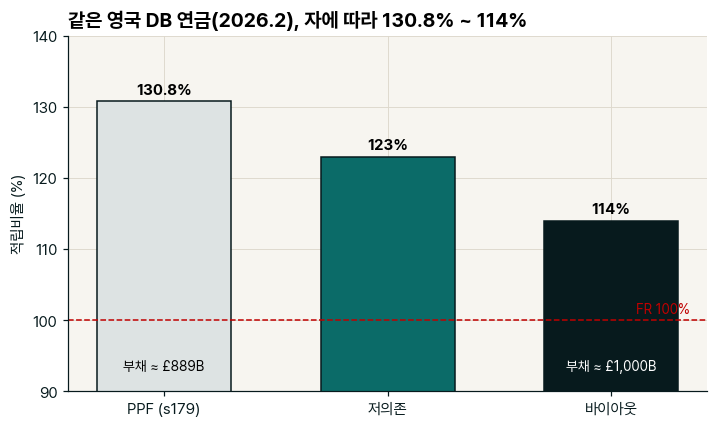

In [9]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
names = ["PPF (s179)", "저의존", "바이아웃"]; frs = [130.8, 123, 114]
bars = ax.bar(names, frs, 0.6, color=["#DDE3E3", TEAL, INK], edgecolor=INK)
for b, v in zip(bars, frs):
    ax.text(b.get_x() + b.get_width() / 2, v + 1, f"{v}%", ha="center", fontweight="bold")
ax.text(0, 93, f"부채 ≈ £{L_ppf:,.0f}B", ha="center", fontsize=9)
ax.text(2, 93, f"부채 ≈ £{L_bo:,.0f}B", ha="center", fontsize=9, color="white")
ax.axhline(100, color=RED, ls="--", lw=1); ax.text(2.35, 101, "FR 100%", color=RED, fontsize=9, ha="right")
ax.set_ylim(90, 140); ax.set_ylabel("적립비율 (%)")
ax.set_title("같은 영국 DB 연금(2026.2), 자에 따라 130.8% ~ 114%")
plt.show()

## 6. 정리
- 부채는 할인율로 **추정**되는 숫자입니다. 국민연금 순부채는 자체 5.5%로 1,542조, 국채 곡선으로 2,122조 — 오후 IC 조건 ① "어느 눈금의 적립비율인가"의 출발점입니다.
- 같은 할인율 문제가 금리 **변화**에 대해 생기면 그것이 금리 위험입니다 → 03 노트북(듀레이션 · DV01).

---
### 확인 결과 요약
이 노트북에서 강의본 숫자와 비교한 항목을 모아 봅니다. 모두 ✓이면 강의본 숫자를 그대로 재현한 것입니다.

In [10]:
# ── 확인 결과 요약 ──
n_ok = sum(ok for _, ok in CHECKS)
print(f"강의본 숫자 확인 {n_ok} / {len(CHECKS)} 통과" + (" — 빠른 모드라 일부 차이는 정상" if FAST else ""))
for label, ok in CHECKS:
    if not ok:
        print("  ✗", label)

강의본 숫자 확인 15 / 15 통과


---
## 바꿔 보기 (연습 문제)

1. 국채 곡선 전체를 −100bp 내리면(`pv_flows(NET, YEARS, shift_bp=-100)`) 순부채와 FR_g는? (07 노트북의 '69% → 49%'와 비교)
2. 자체 할인율이 4.5%라면(소진 2064 시나리오의 수익률) 순부채와 FR은 얼마인가?
3. 영국 DB의 저의존 기준(FR 123%) 부채를 자산 £1,150B로 가정해 역산하라. 바이아웃 부채와 몇 % 차이인가?

아래 빈 셀에서 직접 해 보세요. 위 셀의 함수를 그대로 불러 쓰면 됩니다.

In [11]:
# 여기에 직접 해 보기

In [12]:
# 여기에 직접 해 보기

In [13]:
# 여기에 직접 해 보기